# Clase 19. Payoff Diagrams

> **Objetivo:** Construir e interpretar la gráfica de ganancia y pérdida de cualquier posición con opciones al vencimiento, como base para diseñar y analizar estrategias de trading en las clases 21 y 22.
> 

---

## 1. ¿Qué es un payoff diagram?

Un **payoff diagram** muestra cuánto vale. o gana y pierde. una posición con opciones en función del precio del subyacente **al vencimiento**. Es la herramienta visual fundamental para entender cualquier estrategia antes de implementarla.

Se distinguen dos curvas:

**Payoff bruto:** el valor de la posición al vencimiento, sin considerar lo que se pagó o cobró para entrar.

**P&L neto:** el resultado final después de restar la prima pagada o sumar la prima cobrada. Es lo que realmente gana o pierde el inversionista.

$$
\text{P\&L}_{\text{call comprada}} = \max(S_T - K,\ 0) - C
$$

$$
\text{P\&L}_{\text{put comprada}} = \max(K - S_T,\ 0) - P
$$

---

## 2. El break-even

El **break-even** es el precio del subyacente al vencimiento donde el P&L neto es exactamente cero. Ni ganancia ni pérdida. Es el umbral que el mercado debe cruzar para que la posición sea rentable.

| Posición | Break-even |
| --- | --- |
| Long call | $K + C$ |
| Long put | $K - P$ |
| Short call | $K + C$ |
| Short put | $K - P$ |

Para una long call con K = 680 y C = 9.37, el break-even es 689.37. SPY debe subir por encima de ese nivel para que la posición genere ganancia.

---

## 3. Las cuatro posiciones básicas

Toda estrategia con opciones es una combinación de estas cuatro posiciones:

- Long Call
- Short Call
- Long Put
- Short Put

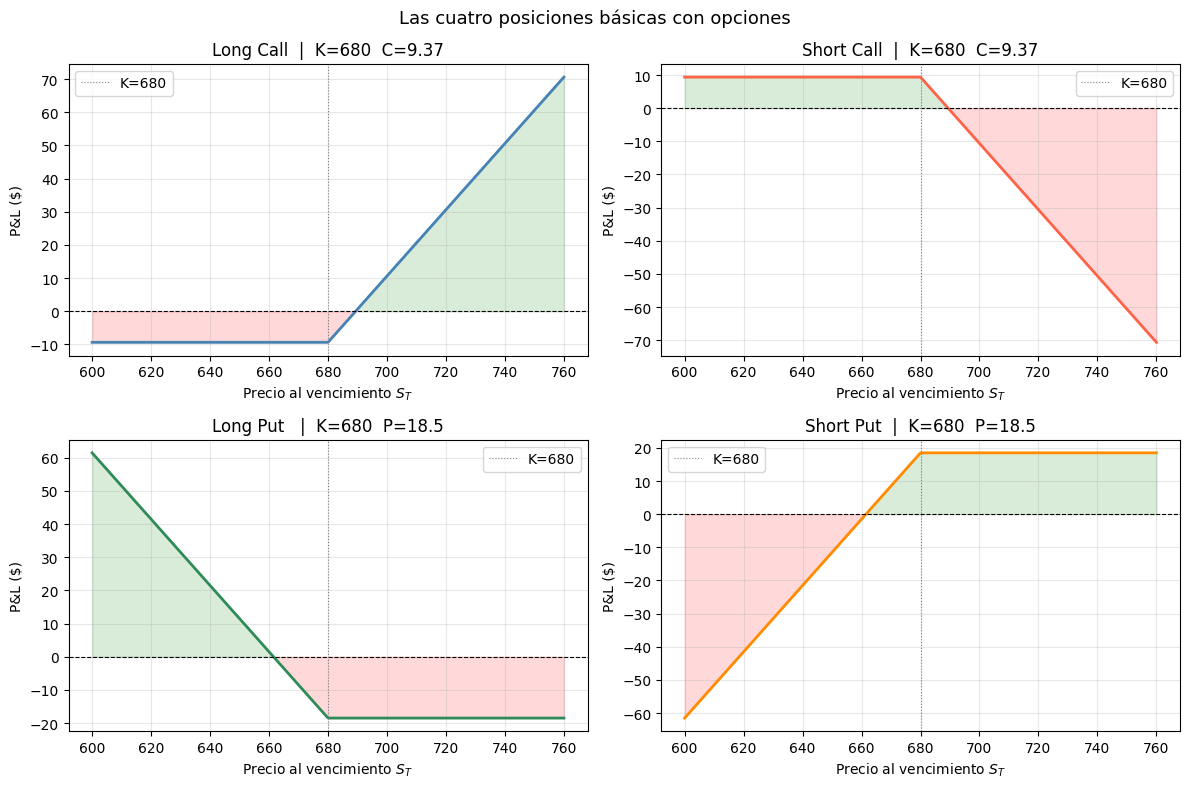

In [1]:
import numpy as np
import matplotlib.pyplot as plt

S_range = np.linspace(600, 760, 500)   # rango de precios al vencimiento
K = 680
C = 9.37    # prima del call
P = 18.50   # prima del put

# --- Payoffs brutos ---
call_long_bruto  =  np.maximum(S_range - K, 0)
call_short_bruto = -np.maximum(S_range - K, 0)
put_long_bruto   =  np.maximum(K - S_range, 0)
put_short_bruto  = -np.maximum(K - S_range, 0)

# --- P&L neto ---
pnl_call_long  = call_long_bruto  - C
pnl_call_short = call_short_bruto + C
pnl_put_long   = put_long_bruto   - P
pnl_put_short  = put_short_bruto  + P

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

configs = [
    (axes[0,0], pnl_call_long,  f'Long Call  |  K={K}  C={C}',  'steelblue'),
    (axes[0,1], pnl_call_short, f'Short Call  |  K={K}  C={C}', 'tomato'),
    (axes[1,0], pnl_put_long,   f'Long Put   |  K={K}  P={P}',  'seagreen'),
    (axes[1,1], pnl_put_short,  f'Short Put  |  K={K}  P={P}',  'darkorange'),
]

for ax, pnl, title, color in configs:
    ax.plot(S_range, pnl, color=color, linewidth=2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(K, color='gray',  linewidth=0.8, linestyle=':', label=f'K={K}')
    ax.fill_between(S_range, pnl, 0, where=(pnl > 0), alpha=0.15, color='green')
    ax.fill_between(S_range, pnl, 0, where=(pnl < 0), alpha=0.15, color='red')
    ax.set_title(title)
    ax.set_xlabel('Precio al vencimiento $S_T$')
    ax.set_ylabel('P&L ($)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Las cuatro posiciones básicas con opciones', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Lectura de cada posición

**Long Call**. pagas la prima C para tener el derecho de comprar a K. Pierdes C si SPY termina por debajo del break-even. La ganancia es ilimitada hacia arriba. 

- Si ST≤K: no ejerces → pierdes la prima C
- Si ST>K: ejerces → ganas ST−K−C

Es una apuesta a que el subyacente sube significativamente.

**Short Call**. cobras la prima C a cambio de la obligación de vender a K si el comprador ejerce. Ganas C si SPY termina por debajo del break-even. La pérdida es ilimitada hacia arriba. El riesgo es asimétrico. 

- Si $S_T≤K$: te quedas la prima
- Si $S_T>K$: pierdes $S_T−K−C$

Es una apuesta a que el subyacente no sube mucho.

**Long Put**. pagas la prima P para tener el derecho de vender a K. Ganas si SPY cae por debajo del break-even. La ganancia máxima es K − P (si SPY llega a cero). 

Es protección contra caídas. Un seguro común para portafolios.

- Si ST≥K: no ejerces → pierdes P
- Si ST<K: ganas K−ST−P

**Short Put**. cobras la prima P a cambio de la obligación de comprar a K si el comprador ejerce. Ganas P si SPY termina por encima del break-even. La pérdida máxima es K − P. 

---

## 5. Payoff bruto vs. P&L neto. la diferencia importa

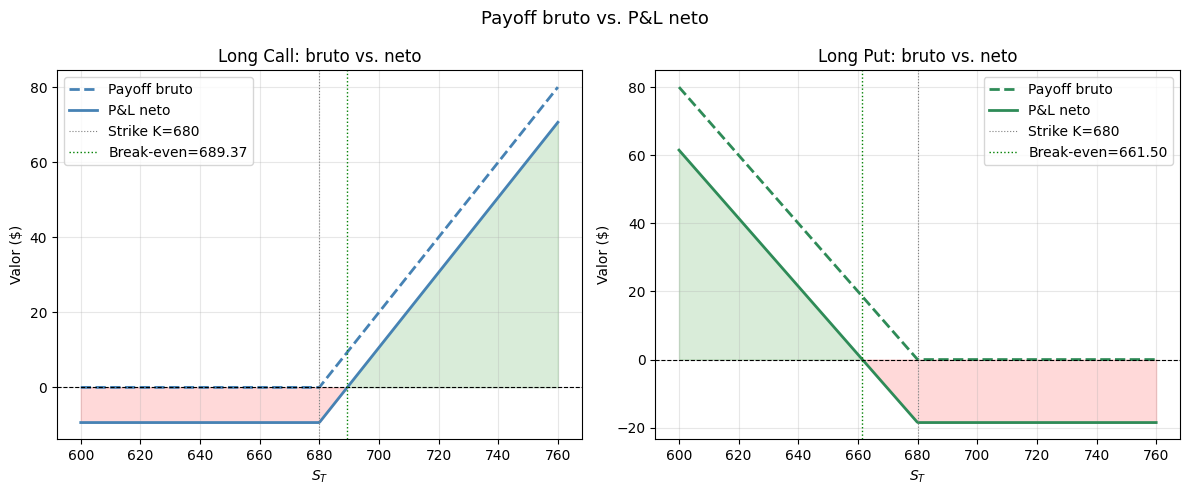

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Long call: comparación bruto vs neto
axes[0].plot(S_range, call_long_bruto, color='steelblue',
             linewidth=2, linestyle='--', label='Payoff bruto')
axes[0].plot(S_range, pnl_call_long,   color='steelblue',
             linewidth=2, label='P&L neto')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].axvline(K,     color='gray', linewidth=0.8,
                linestyle=':', label=f'Strike K={K}')
axes[0].axvline(K + C, color='green', linewidth=1.0,
                linestyle=':', label=f'Break-even={K+C:.2f}')
axes[0].fill_between(S_range, pnl_call_long, 0,
                     where=(pnl_call_long > 0), alpha=0.15, color='green')
axes[0].fill_between(S_range, pnl_call_long, 0,
                     where=(pnl_call_long < 0), alpha=0.15, color='red')
axes[0].set_title('Long Call: bruto vs. neto')
axes[0].set_xlabel('$S_T$')
axes[0].set_ylabel('Valor ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Long put: comparación bruto vs neto
axes[1].plot(S_range, put_long_bruto, color='seagreen',
             linewidth=2, linestyle='--', label='Payoff bruto')
axes[1].plot(S_range, pnl_put_long,   color='seagreen',
             linewidth=2, label='P&L neto')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].axvline(K,     color='gray',  linewidth=0.8,
                linestyle=':', label=f'Strike K={K}')
axes[1].axvline(K - P, color='green', linewidth=1.0,
                linestyle=':', label=f'Break-even={K-P:.2f}')
axes[1].fill_between(S_range, pnl_put_long, 0,
                     where=(pnl_put_long > 0), alpha=0.15, color='green')
axes[1].fill_between(S_range, pnl_put_long, 0,
                     where=(pnl_put_long < 0), alpha=0.15, color='red')
axes[1].set_title('Long Put: bruto vs. neto')
axes[1].set_xlabel('$S_T$')
axes[1].set_ylabel('Valor ($)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Payoff bruto vs. P&L neto', fontsize=13)
plt.tight_layout()
plt.show()

> El payoff bruto siempre empieza en cero. la opción no vale nada si termina OTM. El P&L neto está desplazado hacia abajo por la prima pagada. esa es la pérdida máxima de cualquier posición long.
> 

---

## 6. Función genérica para cualquier estrategia

En las clases 21 y 22 construiremos estrategias combinadas. Esta función acepta cualquier número de posiciones (llamadas *legs*) y calcula el P&L total:

In [3]:
def payoff_estrategia(S_range, legs):
    """
    Calcula el P&L neto de una estrategia con cualquier número de legs.

    Parámetros:
    -----------
    S_range : array de precios al vencimiento
    legs    : lista de dicts, cada uno con:
        tipo     : 'call' o 'put'
        K        : strike
        prima    : prima pagada (+) o cobrada (-)
        posicion : +1 (long) o -1 (short)

    Retorna:
    --------
    Array de P&L neto para cada precio en S_range
    """
    total = np.zeros(len(S_range))

    for leg in legs:
        if leg['tipo'] == 'call':
            payoff = np.maximum(S_range - leg['K'], 0)
        else:
            payoff = np.maximum(leg['K'] - S_range, 0)

        pnl    = leg['posicion'] * (payoff - leg['prima'])
        total += pnl

    return total


def graficar_estrategia(S_range, pnl, titulo, K_lines=None):
    """Grafica el P&L de una estrategia con formato estándar."""
    plt.figure(figsize=(9, 5))
    plt.plot(S_range, pnl, color='steelblue', linewidth=2)
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    if K_lines:
        for k, label in K_lines:
            plt.axvline(k, color='gray', linewidth=0.8,
                        linestyle=':', label=label)
    plt.fill_between(S_range, pnl, 0, where=(pnl > 0),
                     alpha=0.15, color='green', label='Ganancia')
    plt.fill_between(S_range, pnl, 0, where=(pnl < 0),
                     alpha=0.15, color='red',   label='Pérdida')
    plt.xlabel('Precio al vencimiento $S_T$')
    plt.ylabel('P&L ($)')
    plt.title(titulo)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Ejemplo de uso: long call con la función genérica

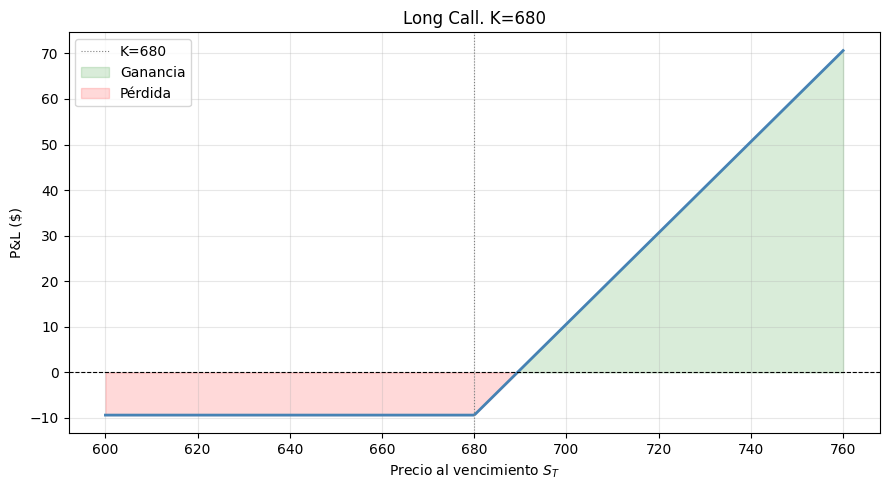

In [4]:
legs_call = [
    {'tipo': 'call', 'K': 680, 'prima': 9.37, 'posicion': +1}
]

pnl = payoff_estrategia(S_range, legs_call)
graficar_estrategia(S_range, pnl, 'Long Call. K=680',
                    K_lines=[(680, 'K=680')])

## Rep 3. Checkpoint 4. Payoff diagrams

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# 1. Obtener dinámicamente los precios mid
tk  = yf.Ticker('SPY')
S0  = tk.fast_info['last_price']
exp = '2026-04-17'
K   = 680

calls = tk.option_chain(exp).calls
puts  = tk.option_chain(exp).puts

row_call = calls[calls['strike'] == K].iloc[0]
row_put  = puts[puts['strike'] == K].iloc[0]

C = (row_call['bid'] + row_call['ask']) / 2
P = (row_put['bid']  + row_put['ask'])  / 2

print(f"S0={S0:.2f}  K={K}  C={C:.4f}  P={P:.4f}")

S0=653.18  K=680  C=3.4100  P=28.4350


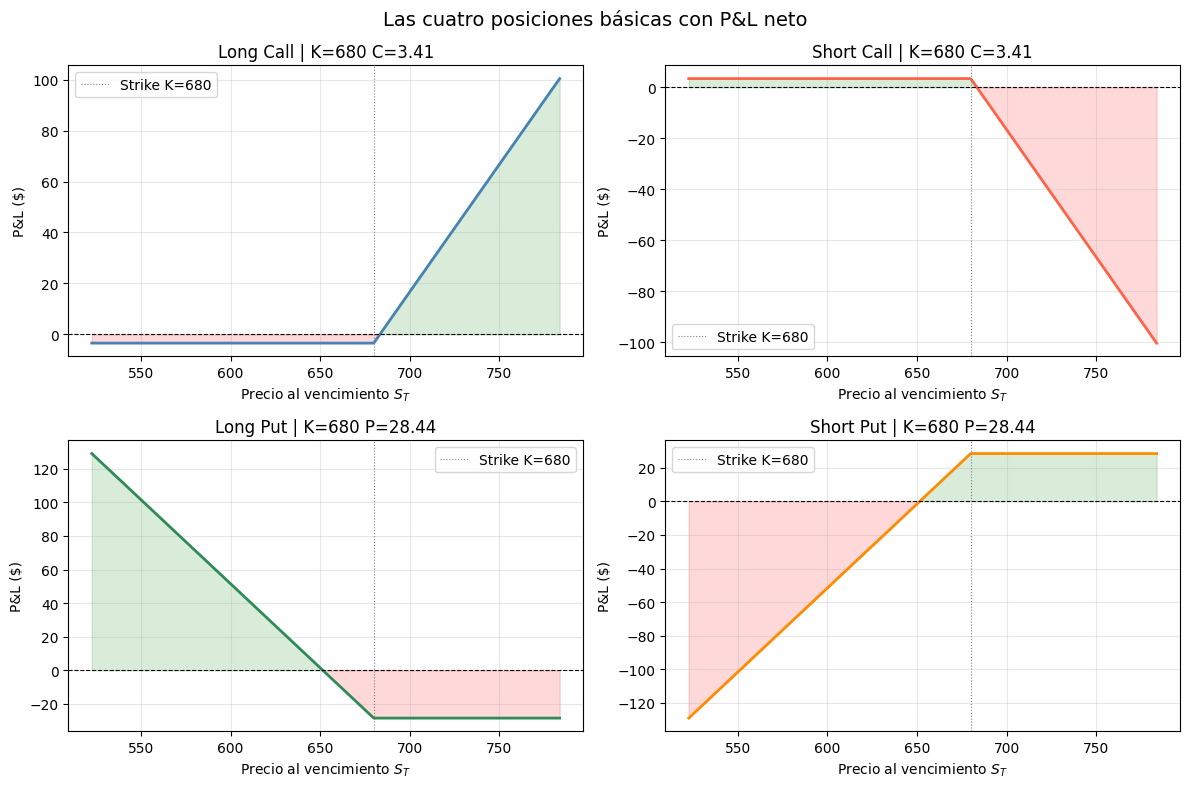

In [7]:

# Generar el plot 2x2 de las cuatro posiciones básicas con P&L neto
S_range = np.linspace(S0 * 0.8, S0 * 1.2, 500)

pnl_call_long = np.maximum(S_range - K, 0) - C
pnl_call_short = -np.maximum(S_range - K, 0) + C
pnl_put_long = np.maximum(K - S_range, 0) - P
pnl_put_short = -np.maximum(K - S_range, 0) + P

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
configs = [
    (axes[0,0], pnl_call_long, f'Long Call | K={K} C={C:.2f}', 'steelblue'),
    (axes[0,1], pnl_call_short, f'Short Call | K={K} C={C:.2f}', 'tomato'),
    (axes[1,0], pnl_put_long, f'Long Put | K={K} P={P:.2f}', 'seagreen'),
    (axes[1,1], pnl_put_short, f'Short Put | K={K} P={P:.2f}', 'darkorange'),
]

for ax, pnl, title, color in configs:
    ax.plot(S_range, pnl, color=color, linewidth=2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(K, color='gray', linewidth=0.8, linestyle=':', label=f'Strike K={K}')
    ax.fill_between(S_range, pnl, 0, where=(pnl > 0), alpha=0.15, color='green')
    ax.fill_between(S_range, pnl, 0, where=(pnl < 0), alpha=0.15, color='red')
    ax.set_title(title)
    ax.set_xlabel('Precio al vencimiento $S_T$')
    ax.set_ylabel('P&L ($)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Las cuatro posiciones básicas con P&L neto', fontsize=14)
plt.tight_layout()
plt.show()

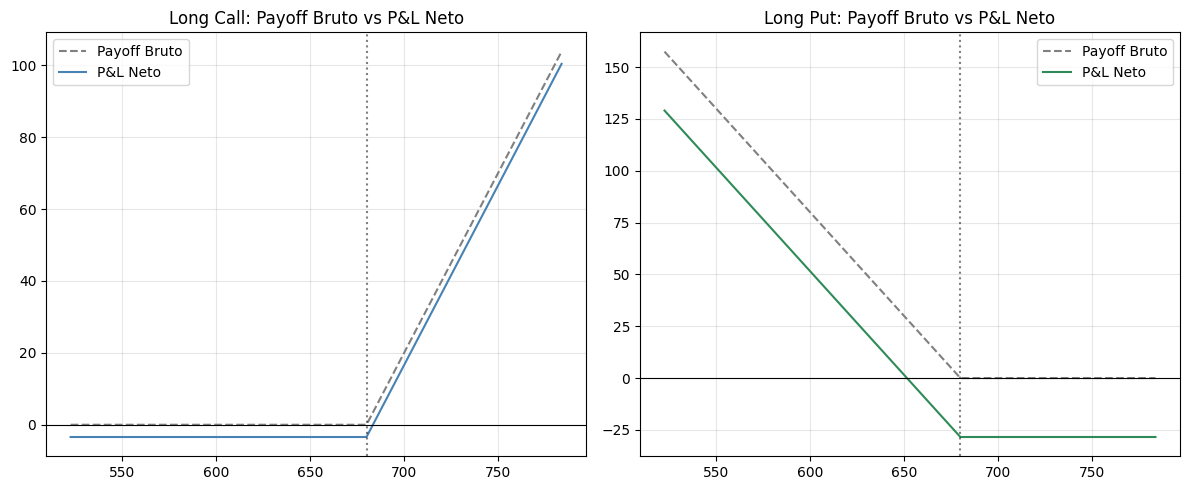

In [8]:
# Comparación de payoff bruto vs P&L neto para Call y Put
call_bruto = np.maximum(S_range - K, 0)
put_bruto = np.maximum(K - S_range, 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Call
ax1.plot(S_range, call_bruto, label='Payoff Bruto', linestyle='--', color='gray')
ax1.plot(S_range, pnl_call_long, label='P&L Neto', color='steelblue')
ax1.axhline(0, color='black', linewidth=0.8)
ax1.axvline(K, color='black', linestyle=':', alpha=0.5)
ax1.set_title('Long Call: Payoff Bruto vs P&L Neto')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Put
ax2.plot(S_range, put_bruto, label='Payoff Bruto', linestyle='--', color='gray')
ax2.plot(S_range, pnl_put_long, label='P&L Neto', color='seagreen')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.axvline(K, color='black', linestyle=':', alpha=0.5)
ax2.set_title('Long Put: Payoff Bruto vs P&L Neto')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# 4. Tabla de Break-evens
data = {
    'Posición': ['Long Call', 'Short Call', 'Long Put', 'Short Put'],
    'Fórmula Break-even': ['K + C', 'K + C', 'K - P', 'K - P'],
    'Valor Break-even': [K + C, K + C, K - P, K - P]
}
df_be = pd.DataFrame(data)
df_be['Distancia vs S0'] = abs(df_be['Valor Break-even'] - S0)
print("\n--- Tabla de Break-Evens ---")
print(df_be.to_string(index=False))


--- Tabla de Break-Evens ---
  Posición Fórmula Break-even  Valor Break-even  Distancia vs S0
 Long Call              K + C           683.410        30.230007
Short Call              K + C           683.410        30.230007
  Long Put              K - P           651.565         1.614993
 Short Put              K - P           651.565         1.614993


## Preguntas:

- **Con el S0 actual, ¿cuál de las cuatro posiciones básicas tiene el break-even más cercano al precio actual? ¿Qué implica eso?**

*Respuesta:*

Las métricas con el break-even más cercano al precio actual (S0=653.18) son Long Put y Short Put. Implica que el mercado está fijando un precio para las opciones Put que refleja casi puramente su valor intrínseco ($680 - 653.18 = 26.82$), con muy poco valor extrínseco. Para que el Long Put empiece a ganar dinero al vencimiento, el SPY solo necesita caer un poco más de 1.6 puntos. Por el contrario, para que el Long Call sea rentable, el SPY necesita un fuerte rally alcista de más de 30 puntos para superar el strike más la prima pagada.

- **Si SPY termina exactamente en K al vencimiento, ¿cuánto gana o pierde cada posición? ¿Por qué?**

*Respuesta:*

Si $S_T = 680$, el valor intrínseco es cero para todas las opciones (ninguna se ejerce). El P&L neto es exactamente la prima inicial:

- Long Call: Pierde el 100% de la prima pagada (-3.41).

- Short Call: Gana el 100% de la prima cobrada (+3.41).

- Long Put: Pierde el 100% de la prima pagada (-28.435).

- Short Put: Gana el 100% de la prima cobrada (+28.435).

Porque al expirar exactamente en el precio Strike, los contratos no tienen valor "In The Money". Los compradores pierden la inversión inicial que hicieron por el derecho, y los vendedores retienen la totalidad del dinero que exigieron al inicio por asumir el riesgo.

- **Compara la pérdida máxima de una long call vs. una short put. ¿Cuál tiene más riesgo? ¿Por qué?**

*Respuesta:*

- Pérdida máxima de Long Call: Está estrictamente limitada a la prima pagada ($C = \mathbf{3.41}$).

- Pérdida máxima de Short Put: Es igual a $K - P$ (si SPY cae a 0). Esto es $680 - 28.435 = \mathbf{651.565}$.


La Short Put asume muchísimo más riesgo. Mientras que en el Long Call tu riesgo está perfectamente acotado a 3.41 por acción desde el primer momento, en el Short Put asumes el riesgo de que el mercado colapse, obligándote a comprar a 680 algo que podría valer muchísimo menos (incluso 0), arriesgando más de 651 puntos.

- **¿En qué escenario de mercado elegirías una long put sobre una short call, si ambas expresan una visión bajista?**

*Respuesta:*

- Elegiría una Long Put ante una expectativa de caída agresiva y/o aumento fuerte de volatilidad. Como el riesgo está limitado a 28.435, pero las ganancias aumentan punto por punto a medida que el precio cae por debajo de 651.56, es ideal para capturar movimientos bajistas bruscos (como un crash de mercado).

- Elegiría una Short Call en un escenario neutral a ligeramente bajista. Si creo que SPY no va a subir por encima de 683.41, pero tampoco espero que colapse (quizás se quede lateralizando), la Short Call me permite ingresar 3.41 de ganancia simplemente por el paso del tiempo, algo que la Long Put no hace (al revés, el paso del tiempo le afecta negativamente).